# Analyze the results from estimating the growth rate parameters

Gets the optimal growth rate values for the nude mice with a single subclone.

It requires that the parameter estimation has been completed and there exists a file with those results. Edit the location of those files below.

## Load required packages

In [1]:
%matplotlib widget
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
from statsmodels.formula import api as smf
import os
import seaborn as sns
from sklearn.metrics import mean_squared_error
import json
from estimator import Estimator
from src import pyxfunc

## User-defined parameters

In [9]:
growth_data_file = "data/growth_data_df.csv"
config_file = "config_files/config_growth_rates.json"

result_path = "results_path/"
figure_save_path = "figures/" # Set to None to not save
plot_results_save_file = "figures/Figure3d_B1B5.csv"

best_value_save_file = "bests/g1_g11.csv" # Set to None to not save

## Setup

In [3]:
groups = ["Grp. B1 nude (100% C1)", "Grp. B5 nude (100% C11)"]
nude_groups = ["Grp. B1 nude (100% C1)", "Grp. B2 nude (80% C1; 20% C11)", "Grp. B3 nude (50% C1; 50% C11)", "Grp. B4 nude (20% C1; 80% C11)", "Grp. B5 nude (100% C11)"]

growth_df = pd.read_csv(growth_data_file)
exclude = [456, 458, 461, 464, 471, 474, 478, 482, 483, 426, 428, 429, 430, 434, 437, 438, 442, 443, 451, 642, 662]
growth_df = growth_df[~(growth_df["id"].isin(exclude))]

es = Estimator(config_file)

## Read in data

In [4]:
# Read in result data
df = []
for fname in [f for f in os.listdir(result_path)]:
    temp = pd.read_csv(result_path+fname)
    temp = temp[~(temp["id"].isin(exclude))]
    df += [temp]
df = pd.concat(df)
df = df.drop_duplicates()
df["log_error"] = np.log(df["error"])
df

,group,id,g1,g11,error,winner,log_error
0,Grp. B1 nude (100% C1),454,0.100,0.000,1.365516e+05,0.0,11.824458
1,Grp. B1 nude (100% C1),455,0.100,0.000,3.171160e+05,0.0,12.667023
2,Grp. B1 nude (100% C1),457,0.100,0.000,3.488821e+05,0.0,12.762489
3,Grp. B1 nude (100% C1),459,0.100,0.000,2.033227e+05,0.0,12.222550
4,Grp. B1 nude (100% C1),454,0.101,0.000,1.347606e+05,0.0,11.811255
...,...,...,...,...,...,...,...
1052,Grp. B5 nude (100% C11),480,0.000,0.249,1.023323e+08,1.0,18.443736
1053,Grp. B5 nude (100% C11),481,0.000,0.249,5.357345e+07,1.0,17.796564
1054,Grp. B5 nude (100% C11),479,0.000,0.250,1.734317e+08,1.0,18.971295
1055,Grp. B5 nude (100% C11),480,0.000,0.250,1.089588e+08,1.0,18.506480


## Plotting functions

In [5]:
def plot_heatmaps_by_mouse(df, error_col):
    fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(12, 6))
    for i in range(2):
        j=0
        for mid in df[df["group"] == groups[i]]["id"].unique():
            if "B1" in groups[i]: col = "g1"
            else: col="g11"
            m_df = df[df["id"] == mid]
            m_df = m_df.sort_values(col, ascending=False)
            sns.heatmap(m_df[error_col].to_numpy().reshape(-1, 1), cmap="hot", yticklabels=[round(j, 3) for j in m_df[col]], ax=axes[i][j])
            axes[i][j].set_xticks(axes[i][j].get_xticks()[::20])
            axes[i][j].set_yticks(axes[i][j].get_yticks()[::20])
            axes[i][j].set_title(mid)
            j += 1
    plt.tight_layout()
    
    if figure_save_path:
        plt.savefig(figure_save_path+"nude_pure_heatmap.svg")
        
    plt.show()

In [21]:
def plot_results(bests):
    plot_results = []
    
    ylim = growth_df[growth_df["group"].isin(nude_groups)]["size"].max()+10
    xlim = growth_df[growth_df["group"].isin(nude_groups)]["day"].max()+2

    # Change figure size at the last part of this line if needed. First value is width, second value is height.
    fig, axes = plt.subplots(nrows=2, ncols=2, sharex=False, figsize=(5,4))
    for i in range(len(groups)):
        axes[0][i].set_ylim([-1, np.abs(ylim)])
        axes[0][i].set_xlim([6, np.abs(xlim)])
        # Plot true data
        group_df = growth_df[growth_df["group"] == groups[i]]
        for mid in group_df["id"].unique():
            axes[0][i].plot(group_df[group_df["id"]==mid]["day"], ((group_df[group_df["id"]==mid]["size"])), color="black", linewidth=1)
            
            # Plot estimated data
            init = es.get_init(groups[i], mid)
            end_time = group_df[group_df["id"]==mid]["day"].max()
            g1 = bests[bests["id"]==mid]["g1"].iloc[0]
            g11 = bests[bests["id"]==mid]["g11"].iloc[0]
            sol = pyxfunc.run(init[0], init[1], init[2], 7.0, end_time, np.inf, 
                                    es.cutoff_0_raw, es.cutoff_0_percent, init[2], g1, g11, 0, 0, 0, 0, 0, 0, 0.01)
            sol[0] = np.asarray(sol[0])
            sol[1] = np.asarray(sol[1])
            
            # plot the winning subline second so it shows up
            if sol[0][-1] > sol[1][-1]: 
                axes[0][i].plot(sol[3], ((sol[1])), color="blue", alpha=0.6, label="Invasive")
                axes[0][i].plot(sol[3], ((sol[0])), color="orange", alpha=0.8, label="Proliferative")
                color = "orange"
            else:
                axes[0][i].plot(sol[3], ((sol[0])), color="orange", alpha=0.8, label="Prolifertative")
                axes[0][i].plot(sol[3], ((sol[1])), color="blue", alpha=0.6, label="Invasive")
                color = "blue"

            plot_results += [np.concat([[groups[i], mid, "C1"], sol[0]])]
            plot_results += [np.concat([[groups[i], mid, "C11"], sol[1]])]
        
        # plot the ratios
        axes[1][i].plot((sol[0]+sol[1]), sol[0]/(sol[0]+sol[1]), color="orange", label="Proliferative")
        axes[1][i].plot((sol[0]+sol[1]), sol[1]/(sol[0]+sol[1]), color="blue", label="Invasive")
        axes[1][i].set_ylim([0, 1])  
            
    plt.tight_layout()

    if figure_save_path:
        plt.savefig(figure_save_path+"nude_pure_predictions.svg")
    
    plt.show()

    return plot_results

## Plot heatmaps

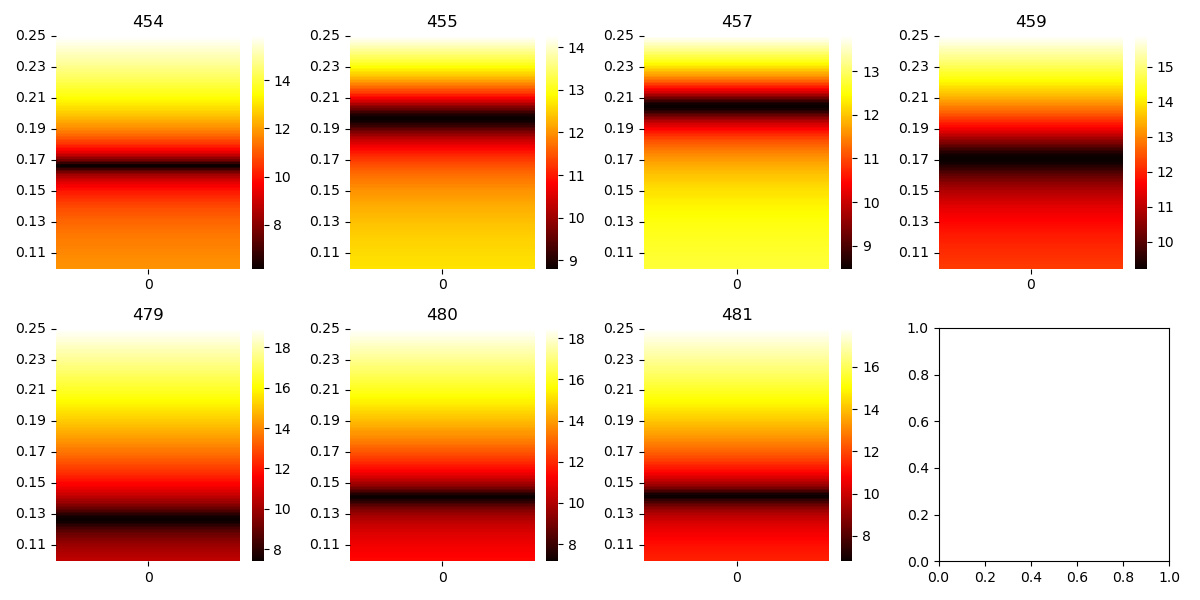

In [7]:
plot_heatmaps_by_mouse(df, "log_error")

## Find best growth rate for each mouse

In [7]:
n = 1
bests = []
for mid in df["id"].unique():
    m_df = df[df["id"] == mid]
    m_df = m_df.sort_values("error").reset_index()
    m_df = m_df[:n]
    bests += [m_df]
bests = pd.concat(bests)
bests

,index,group,id,g1,g11,error,winner,log_error
0,264,Grp. B1 nude (100% C1),454,0.166,0.000,484.206366,0.0,6.182511
0,389,Grp. B1 nude (100% C1),455,0.197,0.000,6611.302283,0.0,8.796536
0,422,Grp. B1 nude (100% C1),457,0.205,0.000,4776.774385,0.0,8.471521
0,287,Grp. B1 nude (100% C1),459,0.171,0.000,10107.337466,0.0,9.221017
0,685,Grp. B5 nude (100% C11),479,0.000,0.127,1630.711363,1.0,7.396772
0,728,Grp. B5 nude (100% C11),480,0.000,0.141,1295.839252,1.0,7.166914
0,732,Grp. B5 nude (100% C11),481,0.000,0.142,886.029319,1.0,6.786750


## Plot simulated curves

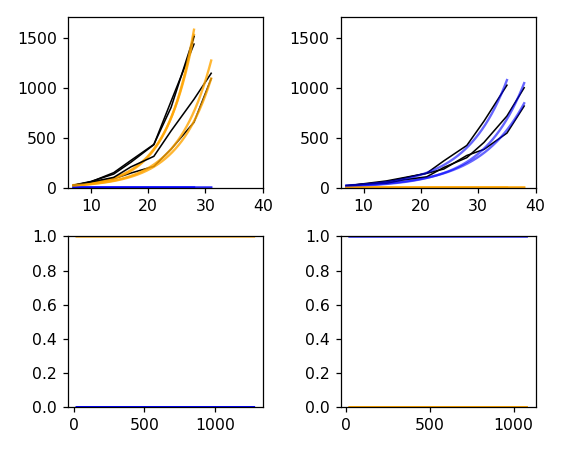

In [22]:
plot_results = plot_results(bests)

In [23]:
plot_results = pd.DataFrame(plot_results, columns=["Group", "ID", "Subclone"]+np.arange(7, 38.01, 0.01).tolist())
if plot_results_save_file:
    plot_results.to_csv(plot_results_save_file, index=False)

## Save optimal values

In [10]:
if best_value_save_file:
    bests.to_csv(best_value_save_file, index=False)